In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_fscore_support

2025-11-05 16:10:37.789392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762359038.025086      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762359038.090753      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# data paths
root = "/kaggle/input/breast-cancer-detection-mri/Breast_Cancer_MRI_Dataset" 
output_dir = "/kaggle/working"
IMAGE_SIZE = (512, 512) 
BATCH_SIZE = 16
SEED = 42
NUM_CLASSES = 1
EPOCHS = 25
LEARNING_RATE = 1e-3

In [3]:
train_dir = os.path.join(root, 'train')
val_dir = os.path.join(root, 'validation')
test_dir = os.path.join(root, 'test')

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=IMAGE_SIZE,
batch_size=BATCH_SIZE,
shuffle=True,
seed=SEED
)


val_ds = tf.keras.preprocessing.image_dataset_from_directory(
val_dir,
labels='inferred',
label_mode='int',
image_size=IMAGE_SIZE,
batch_size=BATCH_SIZE,
shuffle=False
)


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
test_dir,
labels='inferred',
label_mode='int',
image_size=IMAGE_SIZE,
batch_size=BATCH_SIZE,
shuffle=False
)

Found 4000 files belonging to 2 classes.


I0000 00:00:1762359057.630771      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762359057.631482      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


In [5]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


# Data augmentation 
data_augmentation = keras.Sequential([
layers.RandomFlip('horizontal'),
layers.RandomRotation(0.08),
layers.RandomZoom(0.08),
], name='data_augmentation')


# Normalization layer (scale to [0,1])
normalization_layer = layers.Rescaling(1./255)

In [6]:
# Build Model

def get_pretrained_vit(input_shape=(512,512,3), pretrained=True):
    try:
        # KerasCV 
        from keras_cv.models import vit
        print('Using keras_cv.models.vit')
        base = vit.ViT(image_size=input_shape[:2], include_top=False, pretrained_weights='imagenet', include_rescaling=False)
        return base
            
    except Exception as e:
        try:
            # TensorFlow >= 2.10 may have applications.VisionTransformer
            from tensorflow.keras.applications import vit as vit_app
            print('Using tf.keras.applications.vit')
            base = vit_app.VisionTransformer(include_top=False, input_shape=input_shape, weights='imagenet')
            return base
        except Exception:
                print('No pretrained ViT found in this environment. Building a small ViT-like backbone as fallback.')
    
    
    # Fallback: small custom ViT-like encoder (not pretrained)
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same', activation='relu')(inputs)
    x = layers.MaxPool2D(3, strides=2, padding='same')(x)
    # Patchify: use Conv2D to create patches
    patch_size = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    projection_dim = 64
    x = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size)(x) # (batch, h, w, dim)
    x = layers.Reshape((-1, projection_dim))(x)
    # Add a couple of transformer blocks
    for _ in range(4):
        # Layer norm + MHSA
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=projection_dim)(x1, x1)
        x2 = layers.Add()([attention_output, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        mlp = layers.Dense(projection_dim*4, activation='gelu')(x3)
        mlp = layers.Dense(projection_dim)(mlp)
        x = layers.Add()([mlp, x2])
    # Global pooling
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    model = keras.Model(inputs=inputs, outputs=x, name='vit_fallback_backbone')
    return model

In [7]:
# Create input layer
input_shape = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
backbone = get_pretrained_vit(input_shape=input_shape, pretrained=True)

# If backbone outputs feature maps instead of vectors, adapt by pooling
if len(backbone.output_shape) == 4:
    # (batch, h, w, c) -> pool
    x = layers.GlobalAveragePooling2D()(backbone.output)
    backbone_output = x
    base_model = keras.Model(inputs=backbone.input, outputs=backbone_output, name='vit_backbone_with_pool')
else:
    base_model = backbone

print('Backbone summary:')
base_model.summary()

No pretrained ViT found in this environment. Building a small ViT-like backbone as fallback.
Backbone summary:


Model: "vit_fallback_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │  1,048,640 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 64)    │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 64)    │     16,448 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 64)    │     16,448 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 64)    │          0 │ dense_3[0][0],  

 Total params: 1,457,088 (5.56 MB)

 Trainable params: 1,457,088 (5.56 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Freeze backbone for initial training
base_model.trainable = False


inputs = keras.Input(shape=input_shape)
y = data_augmentation(inputs)
y = normalization_layer(y)
# Pass through backbone
y = base_model(y, training=False)
# Add classification head similar style as mobilenet notebook
y = layers.Dropout(0.3)(y)
y = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(y)
y = layers.Dropout(0.3)(y)
# Final single logit for binary
outputs = layers.Dense(1, activation='sigmoid', name='predictions')(y)


model = keras.Model(inputs=inputs, outputs=outputs, name='vit_transfer')


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)


model.summary()

Model: "vit_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vit_fallback_backbone           │ (None, 64)             │     1,457,088 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473,985 (5.62 MB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 1,457,088 (5.56 MB)

In [9]:
# Train head

callbacks = [
    keras.callbacks.ModelCheckpoint("/kaggle/working/Model_ViT.keras", monitor="val_auc", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=10, mode="max", restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

In [10]:
history1 = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks, verbose=1)

Epoch 1/100


I0000 00:00:1762359076.557557     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5544 - auc: 0.5713 - loss: 0.7247
Epoch 1: val_auc improved from -inf to 0.64819, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.5544 - auc: 0.5714 - loss: 0.7247 - val_accuracy: 0.5700 - val_auc: 0.6482 - val_loss: 0.6715 - learning_rate: 0.0010
Epoch 2/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5978 - auc: 0.6304 - loss: 0.6799
Epoch 2: val_auc did not improve from 0.64819
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5977 - auc: 0.6303 - loss: 0.6799 - val_accuracy: 0.5575 - val_auc: 0.6374 - val_loss: 0.6771 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5973 - auc: 0.6456 - loss: 0.6686
Epoch 3: val_auc did not improve from 0.64819
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5972 - auc: 0.6455 - loss: 0.6686 - val_accuracy: 0.5825 - val_auc: 0.6394 - val_loss: 0.6738 - learning_rate: 0

In [11]:
# Fine Tuing

# Unfreeze entire backbone or some top layers
base_model.trainable = True
# Optionally freeze lower layers if backbone has many layers
# for layer in base_model.layers[: -10]:
# layer.trainable = False

# Recompile with lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE * 0.1),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)

In [12]:
# Train head

callbacks_for_fine_tune = [
    keras.callbacks.ModelCheckpoint("/kaggle/working/Model_ViT.keras", monitor="val_auc", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=15, mode="max", restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
]

In [14]:
history2 = model.fit(train_ds, validation_data=val_ds, epochs=70, callbacks=callbacks, verbose=1)

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8084 - auc: 0.8908 - loss: 0.4177
Epoch 1: val_auc improved from 0.92685 to 0.92765, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8083 - auc: 0.8908 - loss: 0.4178 - val_accuracy: 0.8425 - val_auc: 0.9276 - val_loss: 0.3733 - learning_rate: 6.2500e-06
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8052 - auc: 0.8876 - loss: 0.4269
Epoch 2: val_auc improved from 0.92765 to 0.93031, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.8052 - auc: 0.8875 - loss: 0.4269 - val_accuracy: 0.8575 - val_auc: 0.9303 - val_loss: 0.3652 - learning_rate: 6.2500e-06
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8128 - auc: 0.8930 - loss: 0.4187
Epoch 3: val_auc did not improve from 0.93031
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8128 - auc: 0.8929 - loss: 0.4188 - va

In [22]:
# Fine Tuing

# Unfreeze entire backbone or some top layers
base_model.trainable = False
# Optionally freeze lower layers if backbone has many layers
for layer in base_model.layers[: -20]:
    layer.trainable = True

# Recompile with lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)

In [23]:
# Train head

callbacks_for_fine_tune = [
    keras.callbacks.ModelCheckpoint("/kaggle/working/Model_ViT.keras", monitor="val_auc", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=15, mode="max", restore_best_weights=True),
]

In [25]:
model.load_weights("/kaggle/working/Model_ViT.keras")

In [26]:
history3 = model.fit(train_ds, validation_data=val_ds, epochs=70, callbacks=callbacks_for_fine_tune, verbose=1)

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8487 - auc: 0.9203 - loss: 0.3605
Epoch 1: val_auc improved from -inf to 0.97135, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.8487 - auc: 0.9204 - loss: 0.3605 - val_accuracy: 0.8950 - val_auc: 0.9714 - val_loss: 0.2743
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8453 - auc: 0.9180 - loss: 0.3675
Epoch 2: val_auc improved from 0.97135 to 0.97345, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8452 - auc: 0.9180 - loss: 0.3675 - val_accuracy: 0.9125 - val_auc: 0.9735 - val_loss: 0.2461
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8557 - auc: 0.9293 - loss: 0.3442
Epoch 3: val_auc did not improve from 0.97345
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.8557 - auc: 0.9293 - loss: 0.3443 - val_accuracy: 0.8925 - val_auc: 0.9674 - val_loss: 0.2631
Epo

KeyboardInterrupt: 

In [28]:
# Fine Tuing

# Unfreeze entire backbone or some top layers
base_model.trainable = True
# # Optionally freeze lower layers if backbone has many layers
# for layer in base_model.layers[: -20]:
#     layer.trainable = True

# Recompile with lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)

In [29]:
# Train head

callbacks_for_fine_tune = [
    keras.callbacks.ModelCheckpoint("/kaggle/working/Model_ViT.keras", monitor="val_auc", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=15, mode="max", restore_best_weights=True),
]

In [30]:
model.load_weights("/kaggle/working/Model_ViT.keras")

In [31]:
history4 = model.fit(train_ds, validation_data=val_ds, epochs=70, callbacks=callbacks_for_fine_tune, verbose=1)

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9273 - auc: 0.9808 - loss: 0.1795
Epoch 1: val_auc improved from -inf to 0.99264, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - accuracy: 0.9273 - auc: 0.9808 - loss: 0.1795 - val_accuracy: 0.9575 - val_auc: 0.9926 - val_loss: 0.1341
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9422 - auc: 0.9848 - loss: 0.1578
Epoch 2: val_auc did not improve from 0.99264
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.9422 - auc: 0.9848 - loss: 0.1578 - val_accuracy: 0.9600 - val_auc: 0.9921 - val_loss: 0.1322
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9395 - auc: 0.9854 - loss: 0.1560
Epoch 3: val_auc improved from 0.99264 to 0.99290, saving model to /kaggle/working/Model_ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.9396 - auc: 0.9854 - loss: 0.1560 - val_accuracy: 0.9650 - val_auc: 0.9929 - val_loss: 0.1171
Epo

KeyboardInterrupt: 

In [32]:
# Evaluate after fine tuning

model.load_weights("/kaggle/working/Model_ViT.keras")

def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)

print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

Best threshold: 0.14694251
Validation metrics: {'auc': 0.9929250000000001, 'precision': 0.975, 'recall': 0.975, 'f1': 0.975, 'specificity': 0.975, 'cm': array([[195,   5],
       [  5, 195]])}
Test metrics: {'auc': 0.973825, 'precision': 0.8873239436619719, 'recall': 0.945, 'f1': 0.9152542372881356, 'specificity': 0.88, 'cm': array([[176,  24],
       [ 11, 189]])}


In [33]:
# Evaluate after fine tuning

model.load_weights("/kaggle/input/vit/tensorflow2/default/1/Model_ViT (4).keras")

def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)

print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

Best threshold: 0.19235176
Validation metrics: {'auc': 0.9927750000000001, 'precision': 0.9846938775510204, 'recall': 0.965, 'f1': 0.9747474747474748, 'specificity': 0.985, 'cm': array([[197,   3],
       [  7, 193]])}
Test metrics: {'auc': 0.968925, 'precision': 0.9215686274509803, 'recall': 0.94, 'f1': 0.9306930693069307, 'specificity': 0.92, 'cm': array([[184,  16],
       [ 12, 188]])}


In [34]:
# Load the model
from tensorflow.keras.models import load_model
vit_model = load_model("/kaggle/input/vit/tensorflow2/default/1/Model_ViT (4).keras")

In [36]:
# !pip install tensorflow_model_optimization
import tensorflow_model_optimization as tfmot

In [37]:
# Create the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(vit_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_quant_model = converter.convert()

Saved artifact at '/tmp/tmppncp7gyz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134328689720784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581020048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581019472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581020816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581021008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581018704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581018896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581022928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581022352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134326581023696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1343265810231

W0000 00:00:1762362409.748447      37 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762362409.748506      37 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1762362409.790012      37 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


In [38]:
# Save the quantized model

with open("/kaggle/working/Model_ViT_F32.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [39]:
vit_model = load_model("/kaggle/input/vit/tensorflow2/default/1/Model_ViT (4).keras")

In [41]:
# Create the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(vit_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Convert the model
tflite_quant_model = converter.convert()

Saved artifact at '/tmp/tmpr_ljoxnr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134307969757456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969759952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969760528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969755344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969761104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969755536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969760144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969754768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969755728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134307969754000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1343079697545

W0000 00:00:1762362542.671022      37 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762362542.671076      37 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [42]:
# Save the quantized model

with open("/kaggle/working/Model_ViT_F16.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [43]:
files = [
    "/kaggle/working/Model_ViT.keras",
    "/kaggle/working/Model_ViT_F32.tflite",
    "/kaggle/working/Model_ViT_F16.tflite"
    
]

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

/kaggle/working/Model_ViT.keras: 17.12 MB
/kaggle/working/Model_ViT_F32.tflite: 1.53 MB
/kaggle/working/Model_ViT_F16.tflite: 2.87 MB


In [44]:
from PIL import Image

# Path to your test dataset
test_dir = "/kaggle/input/breast-cancer-detection-mri/Breast_Cancer_MRI_Dataset/test"

# Load images and labels
def load_test_data(test_dir, img_size=(512, 512)):
    images = []
    labels = []
    class_map = {"neg": 0, "pos": 1}

    for class_name in ["neg", "pos"]:
        class_path = os.path.join(test_dir, class_name)
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path).convert("RGB")
            img = img.resize(img_size)
            img_array = np.array(img, dtype=np.float32) / 255.0  # normalize if needed
            images.append(img_array)
            labels.append(class_map[class_name])
    
    return np.array(images), np.array(labels)

In [45]:
test_images, test_labels = load_test_data(test_dir)

In [46]:
## Evaluate quantized model

# dynamic range

# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Model_ViT_F32.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Best threshold: 0.21649219
Validation metrics: {'auc': 0.9927, 'precision': 0.9896907216494846, 'recall': 0.96, 'f1': 0.9746192893401014, 'specificity': 0.99, 'cm': array([[198,   2],
       [  8, 192]])}
Test metrics: {'auc': 0.9690249999999999, 'precision': 0.9447236180904522, 'recall': 0.94, 'f1': 0.9423558897243106, 'specificity': 0.945, 'cm': array([[189,  11],
       [ 12, 188]])}


Best threshold: 0.21649219

Test metrics:
auc: 0.9690
precision: 0.9447
recall: 0.9400
f1: 0.9424
specificity: 0.9450


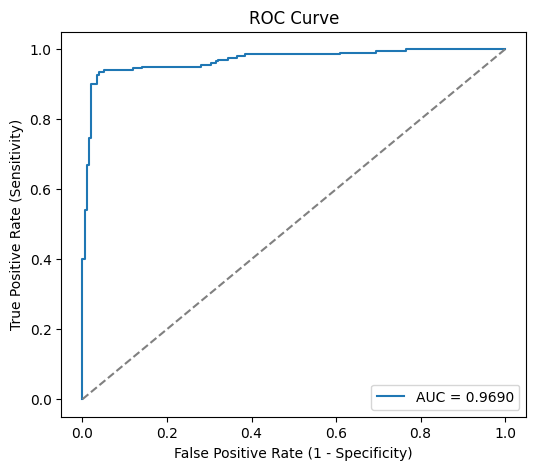

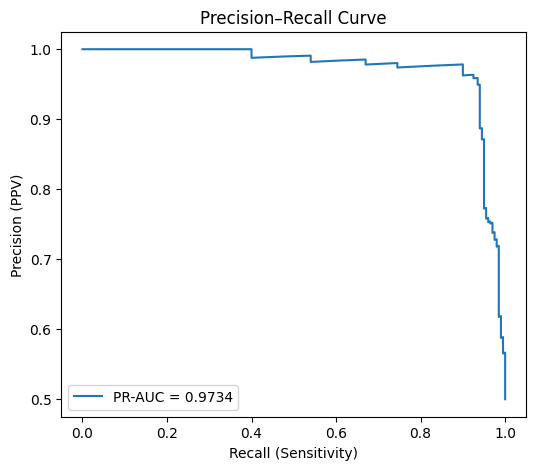

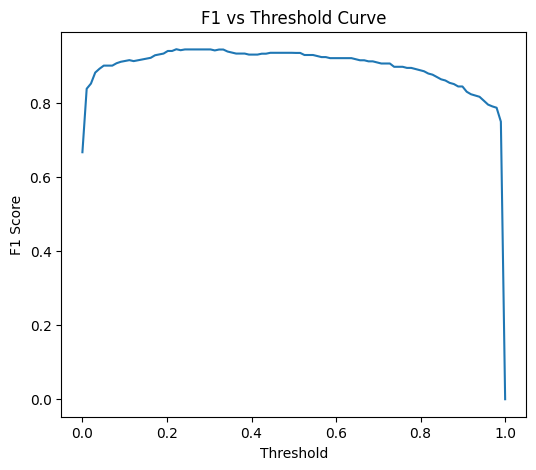

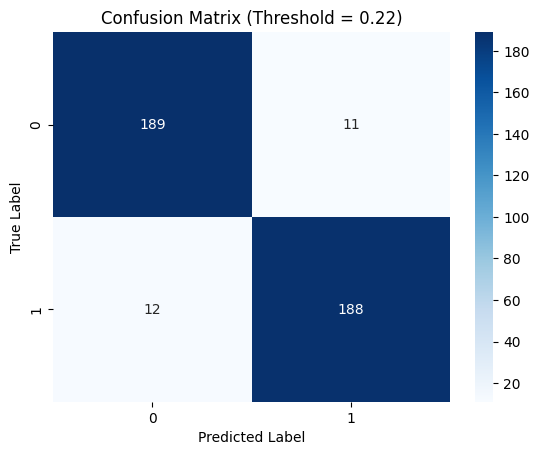

ROC-AUC: 0.9690
PR-AUC: 0.9734


In [47]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# Get predictions from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class model outputs
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Find best threshold using Youden’s J statistic
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_thr = thr[np.argmax(youden)]
    return best_thr, y_true, y_prob


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm, 
                y_true=y_true, y_prob=y_prob)


# Plot all diagnostic curves
def plot_medical_curves(y_true, y_prob, threshold=0.5):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

    # F1 vs Threshold Curve
    thresholds = np.linspace(0, 1, 100)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold Curve")
    plt.show()

    # Confusion Matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Model_ViT_F32.tflite")
interpreter.allocate_tensors()


# Find best threshold using validation set
thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)

# Compute metrics for test set
test_metrics = metrics_at_threshold_tflite(interpreter, test_ds, thr)
print("\nTest metrics:")
for k, v in test_metrics.items():
    if k not in ["y_true", "y_prob", "cm"]:
        print(f"{k}: {v:.4f}")

# Plot all diagnostic curves for test set
plot_medical_curves(test_metrics["y_true"], test_metrics["y_prob"], threshold=thr)

In [48]:
# tflite f16 

# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Model_ViT_F16.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

Best threshold: 0.19232476
Validation metrics: {'auc': 0.9927750000000001, 'precision': 0.9846938775510204, 'recall': 0.965, 'f1': 0.9747474747474748, 'specificity': 0.985, 'cm': array([[197,   3],
       [  7, 193]])}
Test metrics: {'auc': 0.968925, 'precision': 0.9215686274509803, 'recall': 0.94, 'f1': 0.9306930693069307, 'specificity': 0.92, 'cm': array([[184,  16],
       [ 12, 188]])}


Best threshold: 0.19232476

Test metrics:
auc: 0.9689
precision: 0.9216
recall: 0.9400
f1: 0.9307
specificity: 0.9200


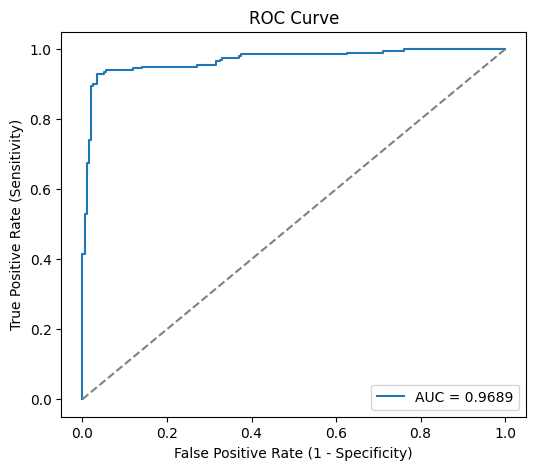

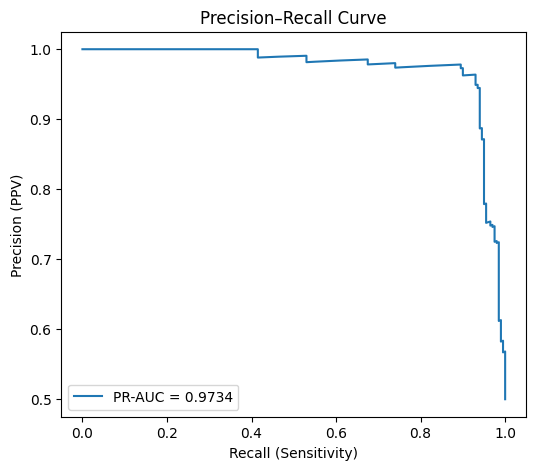

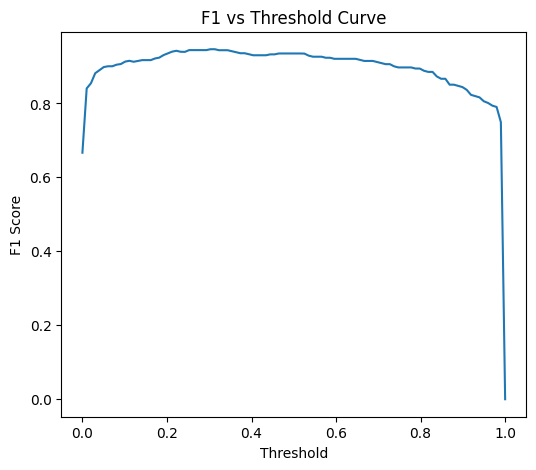

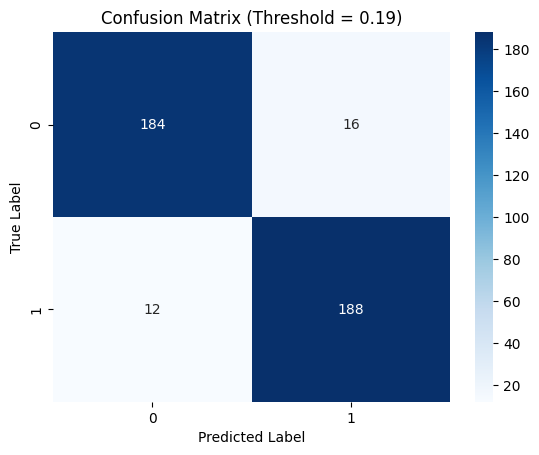

ROC-AUC: 0.9689
PR-AUC: 0.9734


In [49]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# Get predictions from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class model outputs
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Find best threshold using Youden’s J statistic
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_thr = thr[np.argmax(youden)]
    return best_thr, y_true, y_prob


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm, 
                y_true=y_true, y_prob=y_prob)


# Plot all diagnostic curves
def plot_medical_curves(y_true, y_prob, threshold=0.5):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

    # F1 vs Threshold Curve
    thresholds = np.linspace(0, 1, 100)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold Curve")
    plt.show()

    # Confusion Matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Model_ViT_F16.tflite")
interpreter.allocate_tensors()


# Find best threshold using validation set
thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)

# Compute metrics for test set
test_metrics = metrics_at_threshold_tflite(interpreter, test_ds, thr)
print("\nTest metrics:")
for k, v in test_metrics.items():
    if k not in ["y_true", "y_prob", "cm"]:
        print(f"{k}: {v:.4f}")

# Plot all diagnostic curves for test set
plot_medical_curves(test_metrics["y_true"], test_metrics["y_prob"], threshold=thr)